# 05 - Final Report
## Loan Risk Assessment System

**Objective:** Summarize the end-to-end project — from raw data to a production deployment recommendation — for stakeholder review.

**Contents:**
1. Project overview
2. Final model comparison table
3. Key visualizations
4. Deployment recommendation
5. Conclusion & future improvements

## 1. Project Overview

The Loan Risk Assessment System predicts whether a loan application should be **approved** or **rejected** based on applicant demographic and financial attributes. Three classification models were trained and rigorously compared: **Logistic Regression**, **Decision Tree**, and **Random Forest**.

The pipeline covers the full ML lifecycle: data cleaning, feature engineering, exploratory data analysis, model training with hyperparameter tuning (GridSearchCV), evaluation, and a final banking deployment recommendation.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
from IPython.display import Image, Markdown, display
from src import config

comparison_df = pd.read_csv(config.MODEL_COMPARISON_PATH)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest,0.747967,0.801980,0.880435,0.839378,0.685484
1,Logistic Regression,0.715447,0.813187,0.804348,0.808743,0.673913
2,Decision Tree,0.707317,0.811111,0.793478,0.802198,0.664797


## 2. Model Comparison Summary

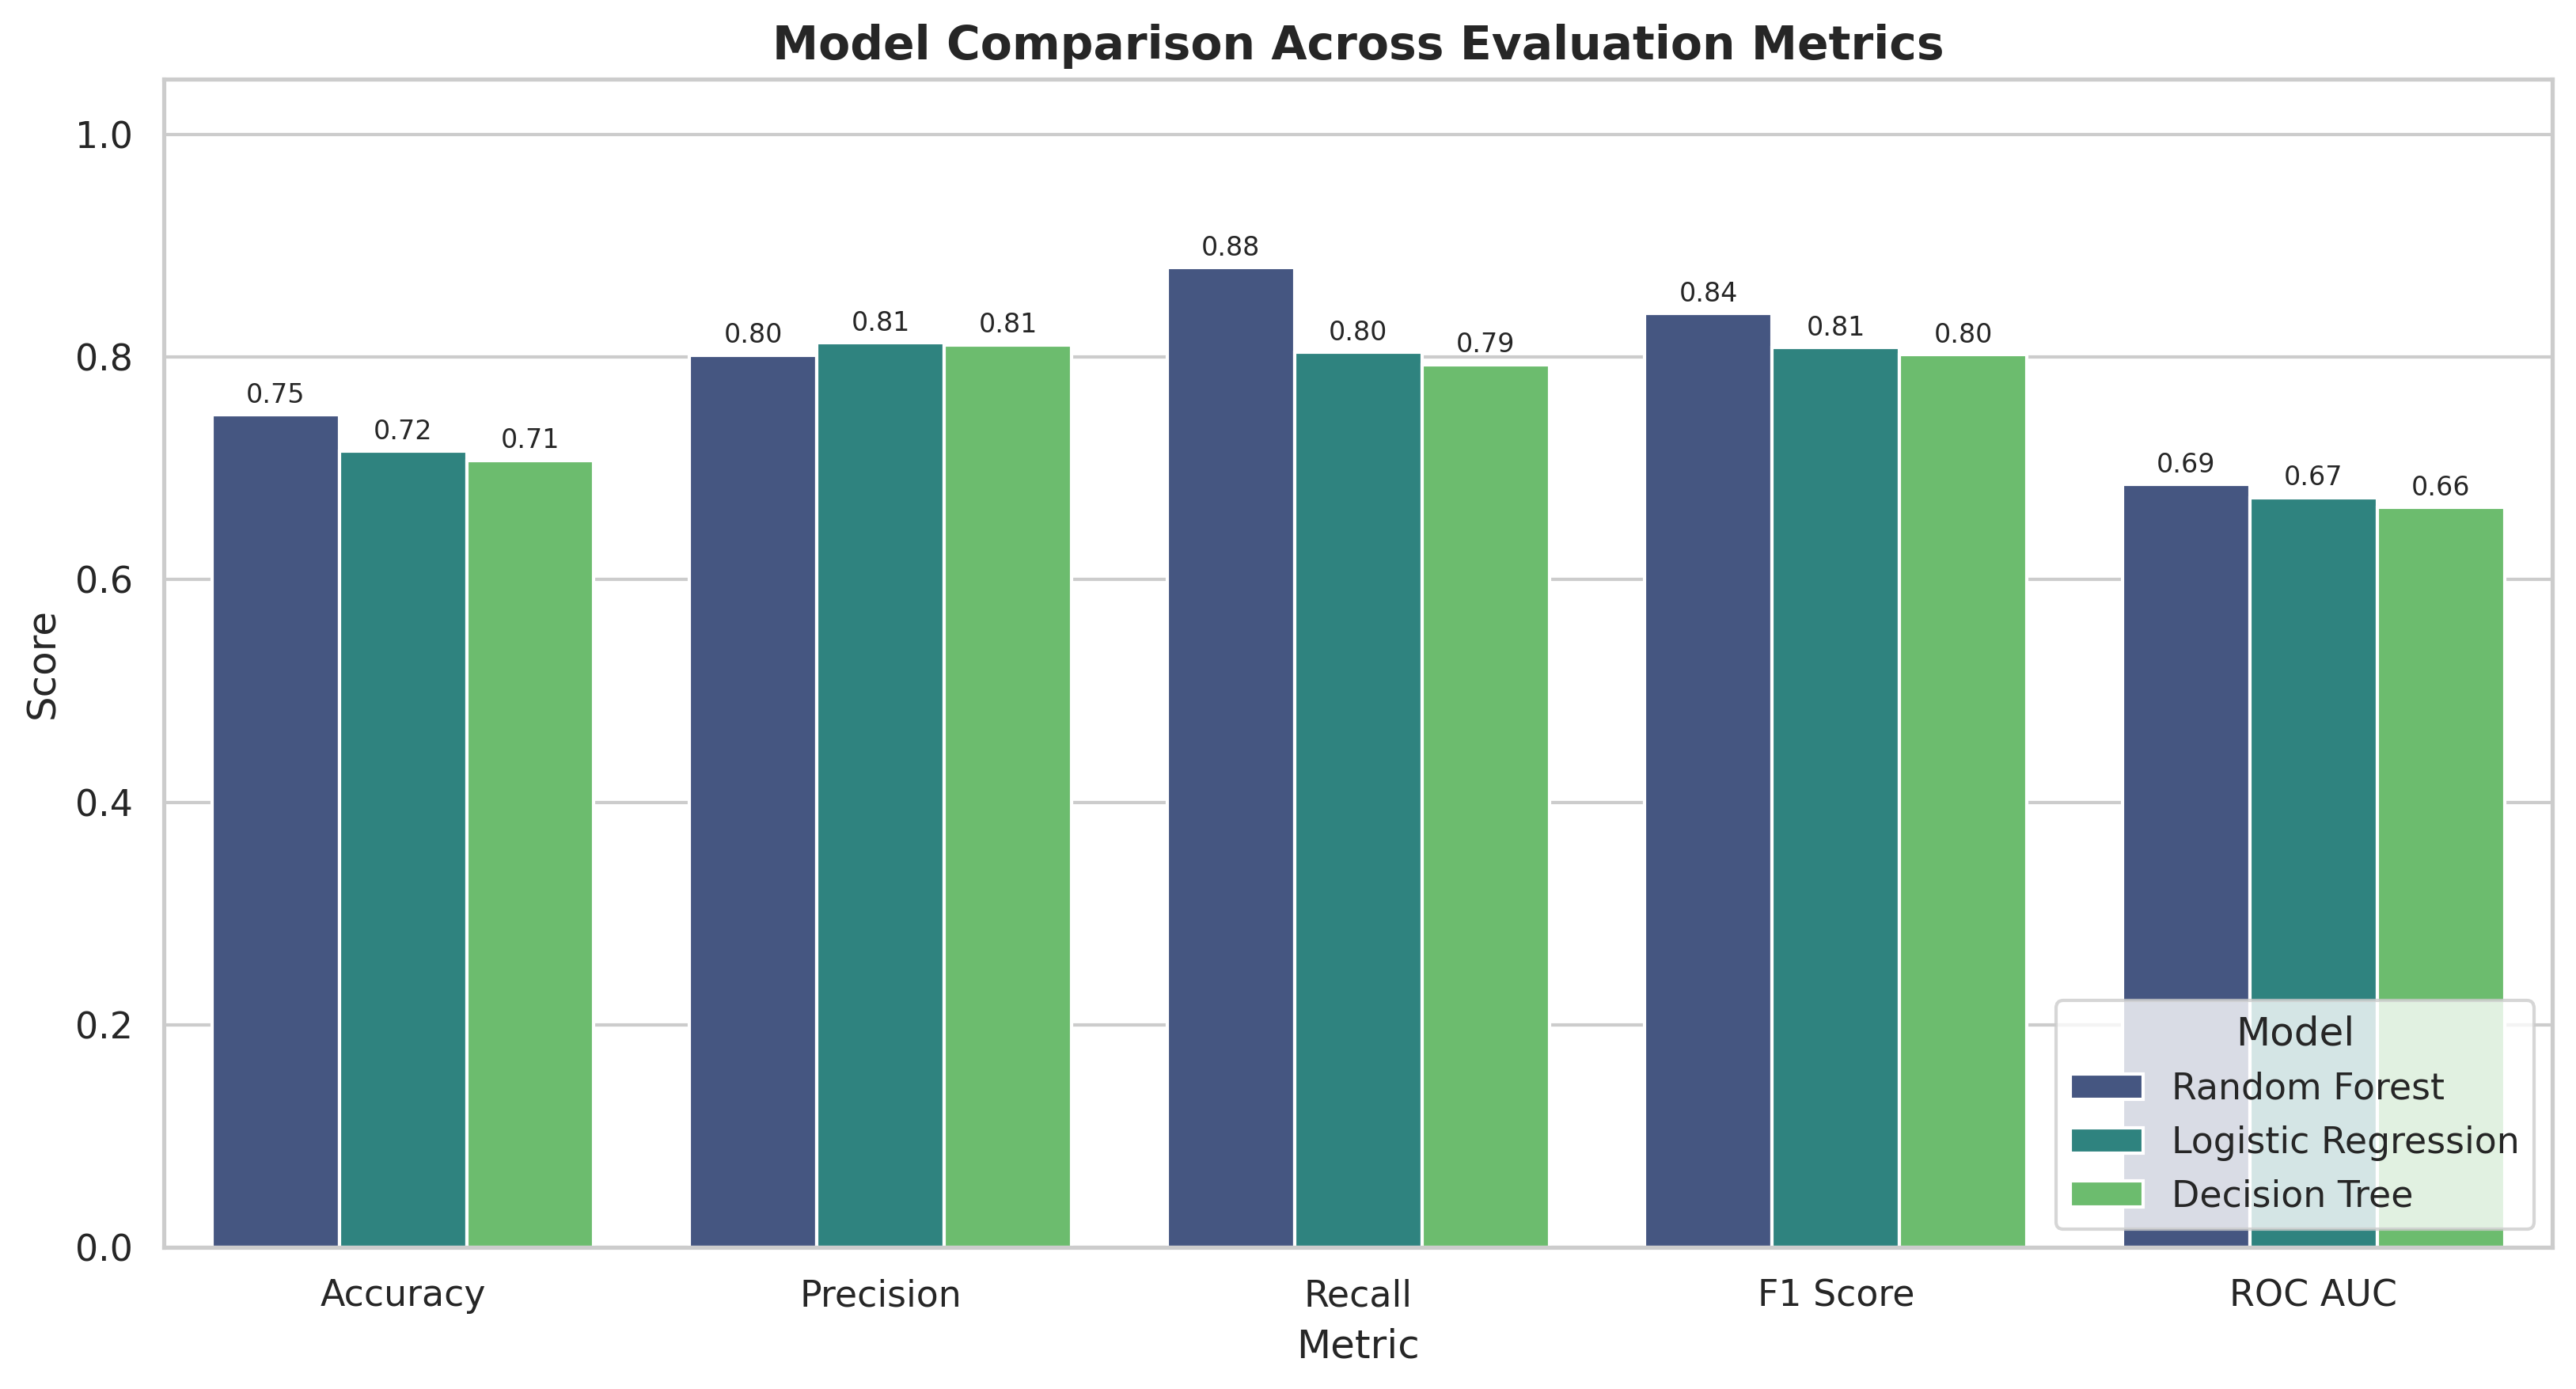

In [2]:
display(Image(filename=str(config.IMAGES_DIR / 'model_comparison.png')))

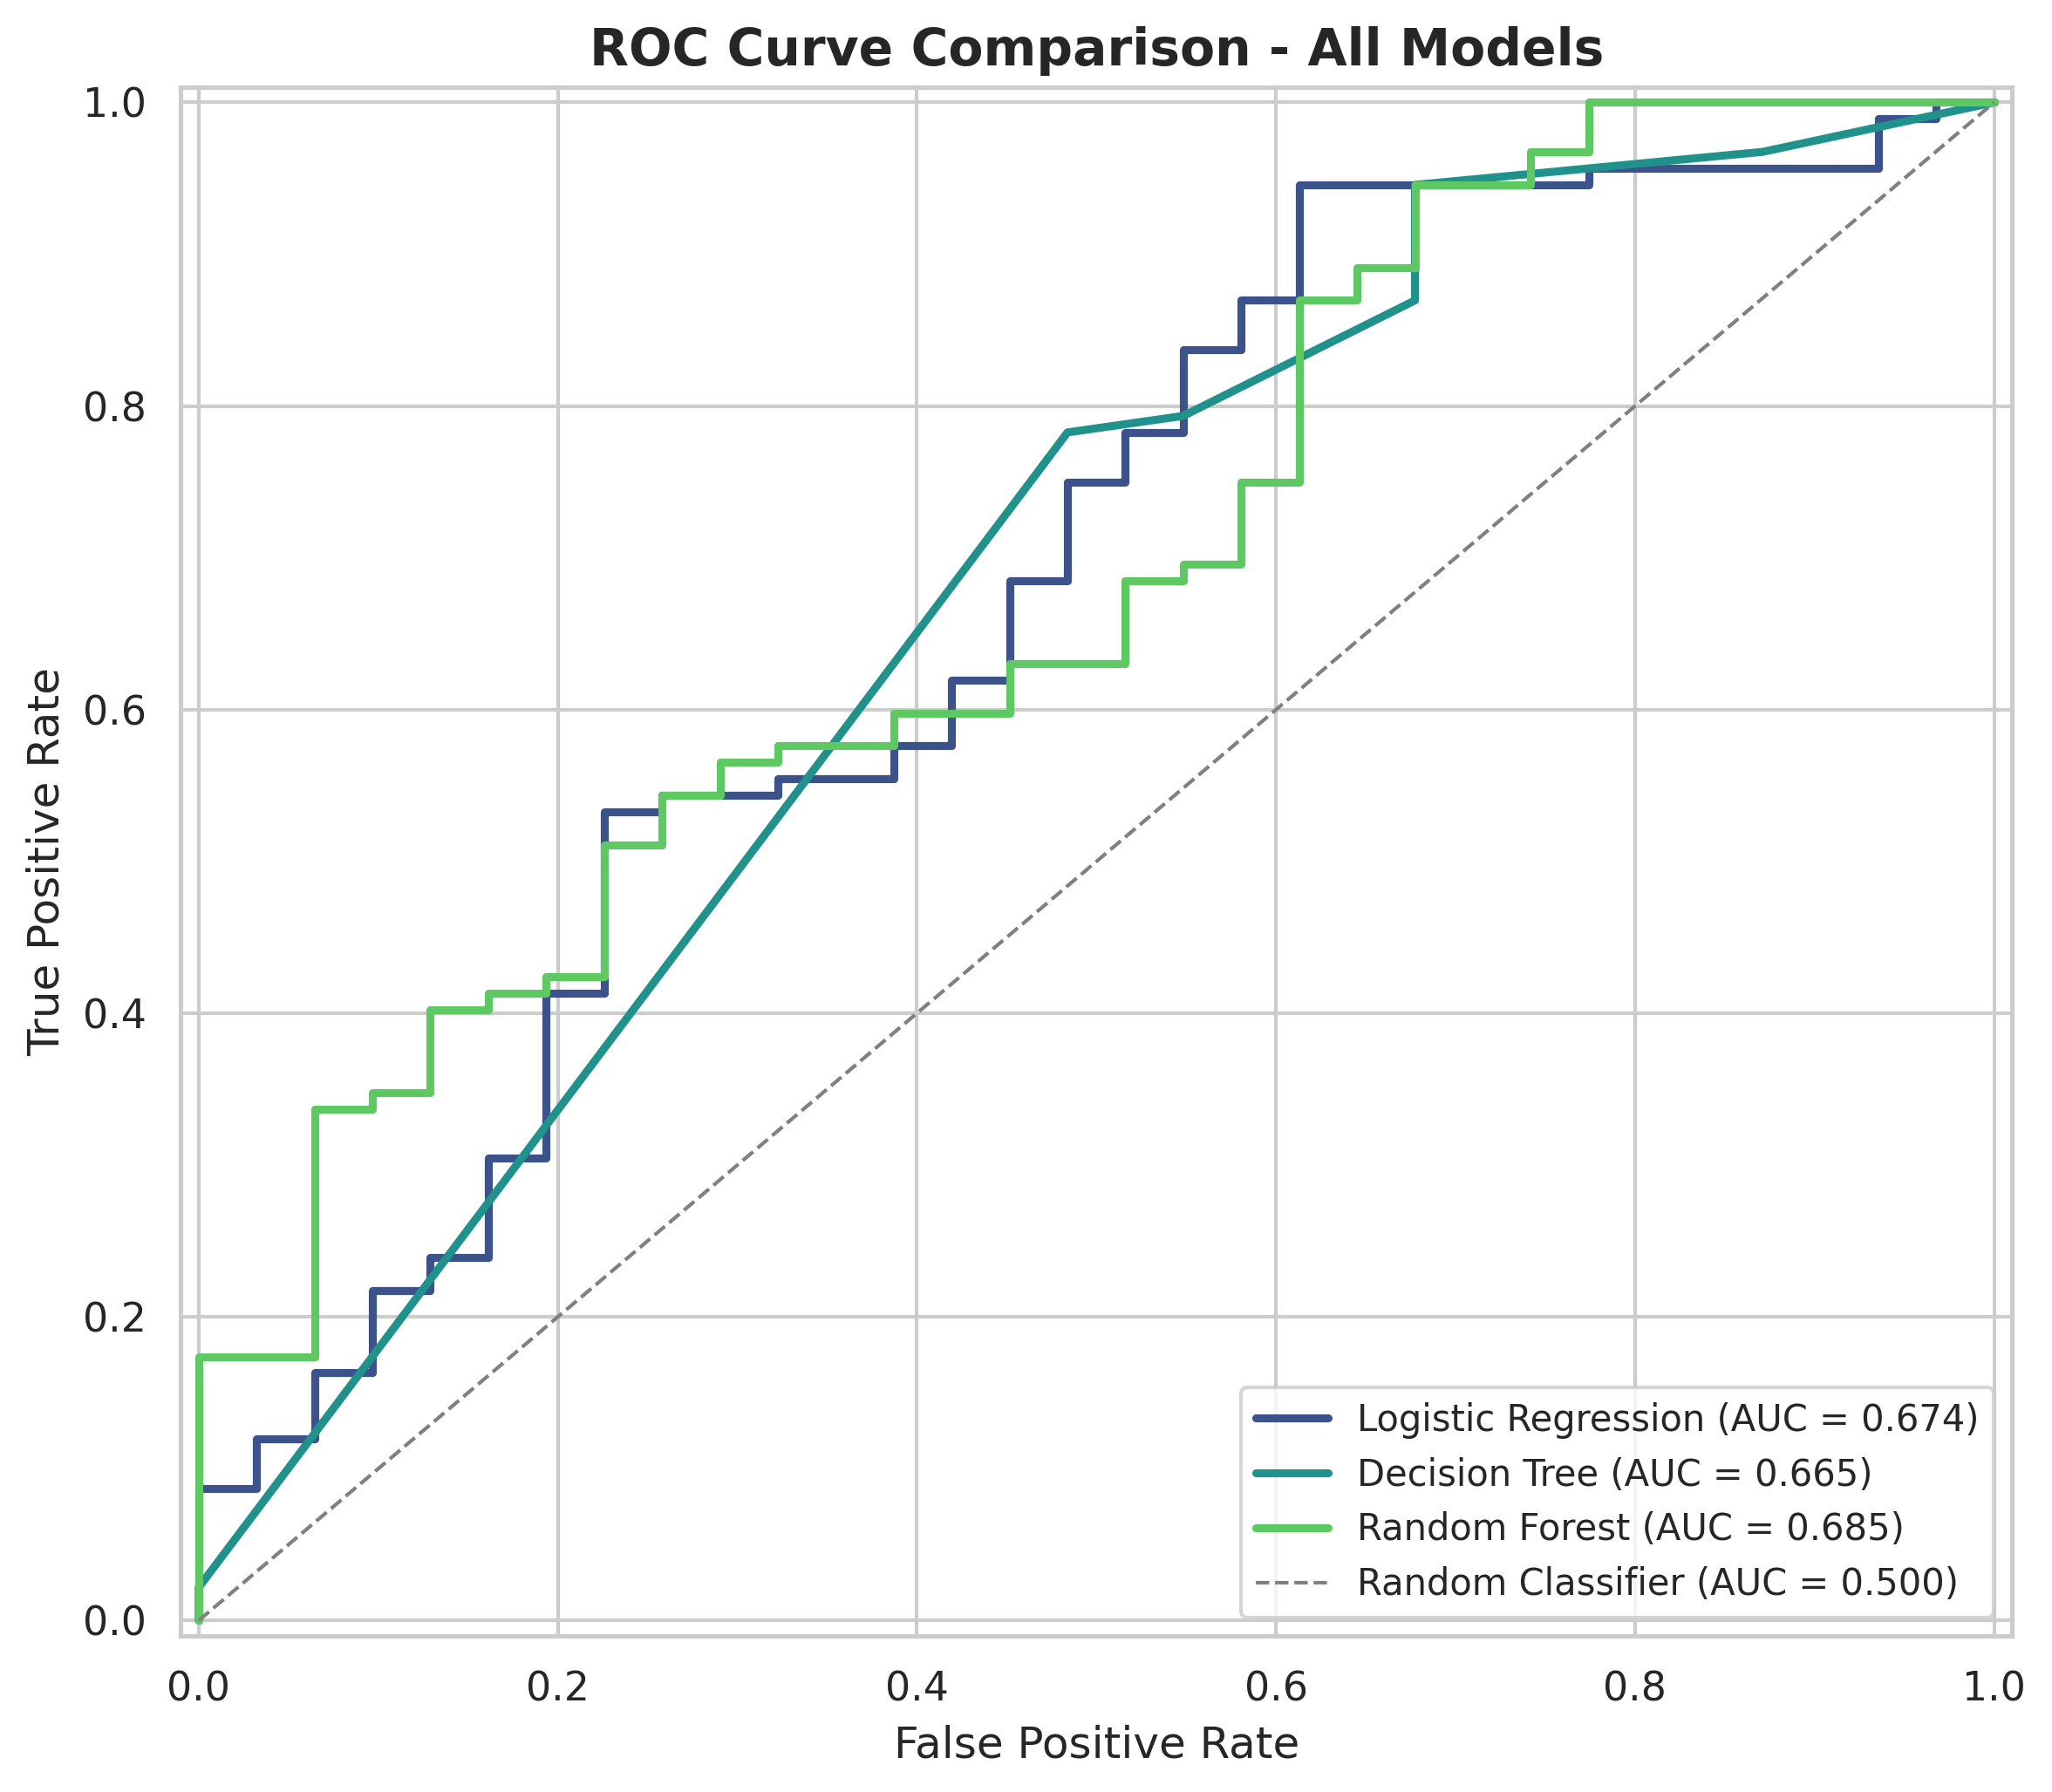

In [3]:
display(Image(filename=str(config.IMAGES_DIR / 'roc_curve.png')))

## 3. Key Visualizations

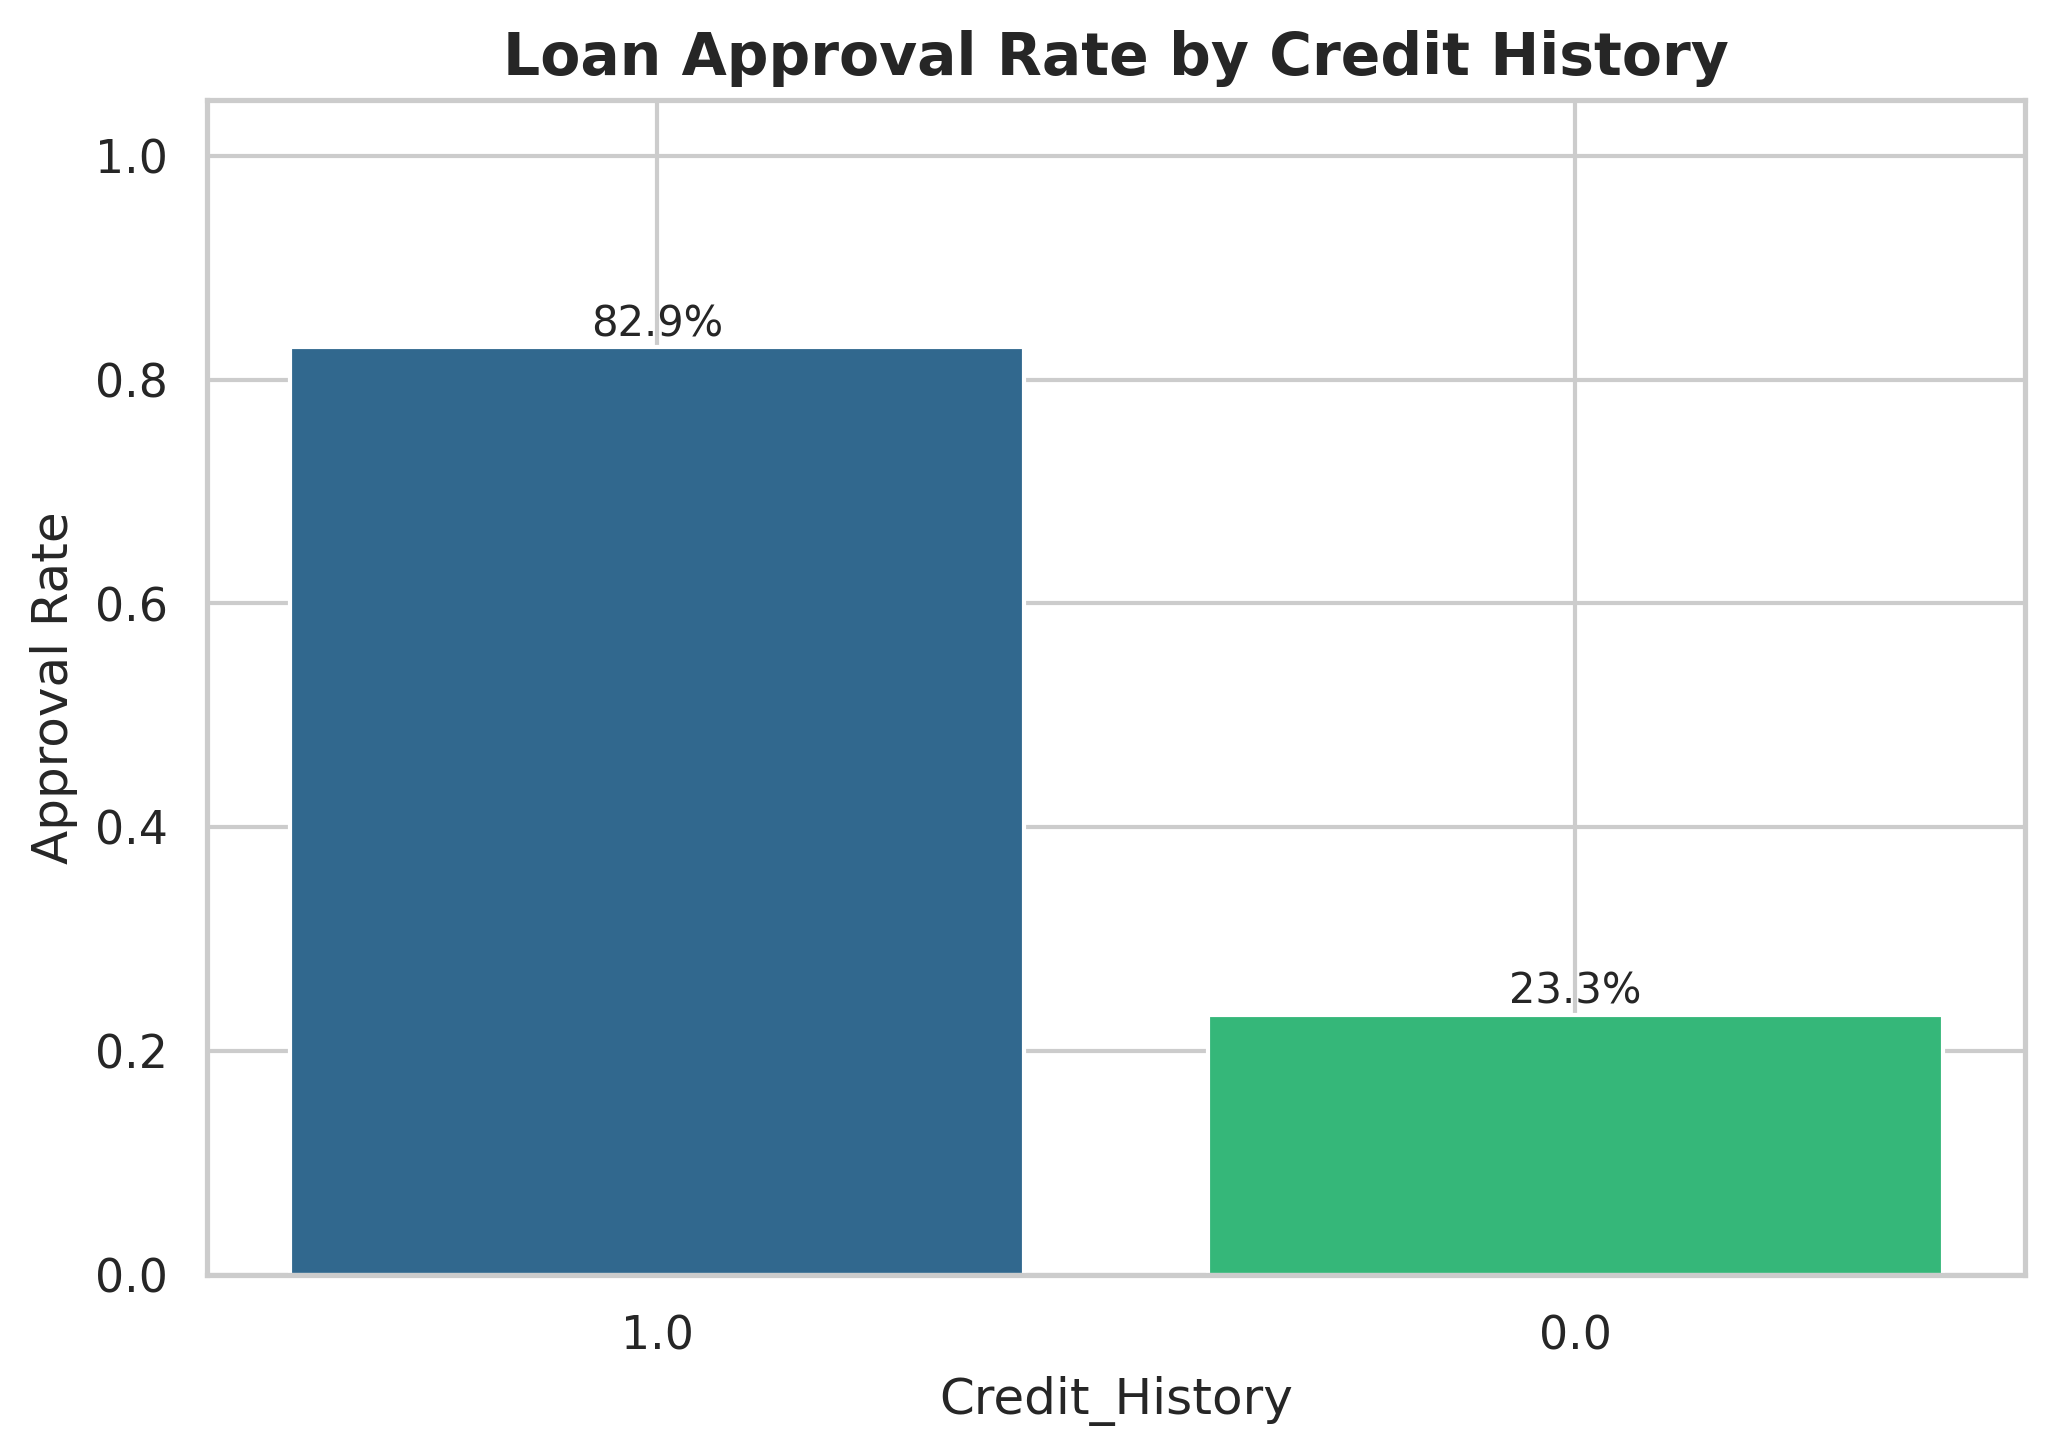

In [4]:
display(Image(filename=str(config.IMAGES_DIR / 'approval_credit_history.png')))

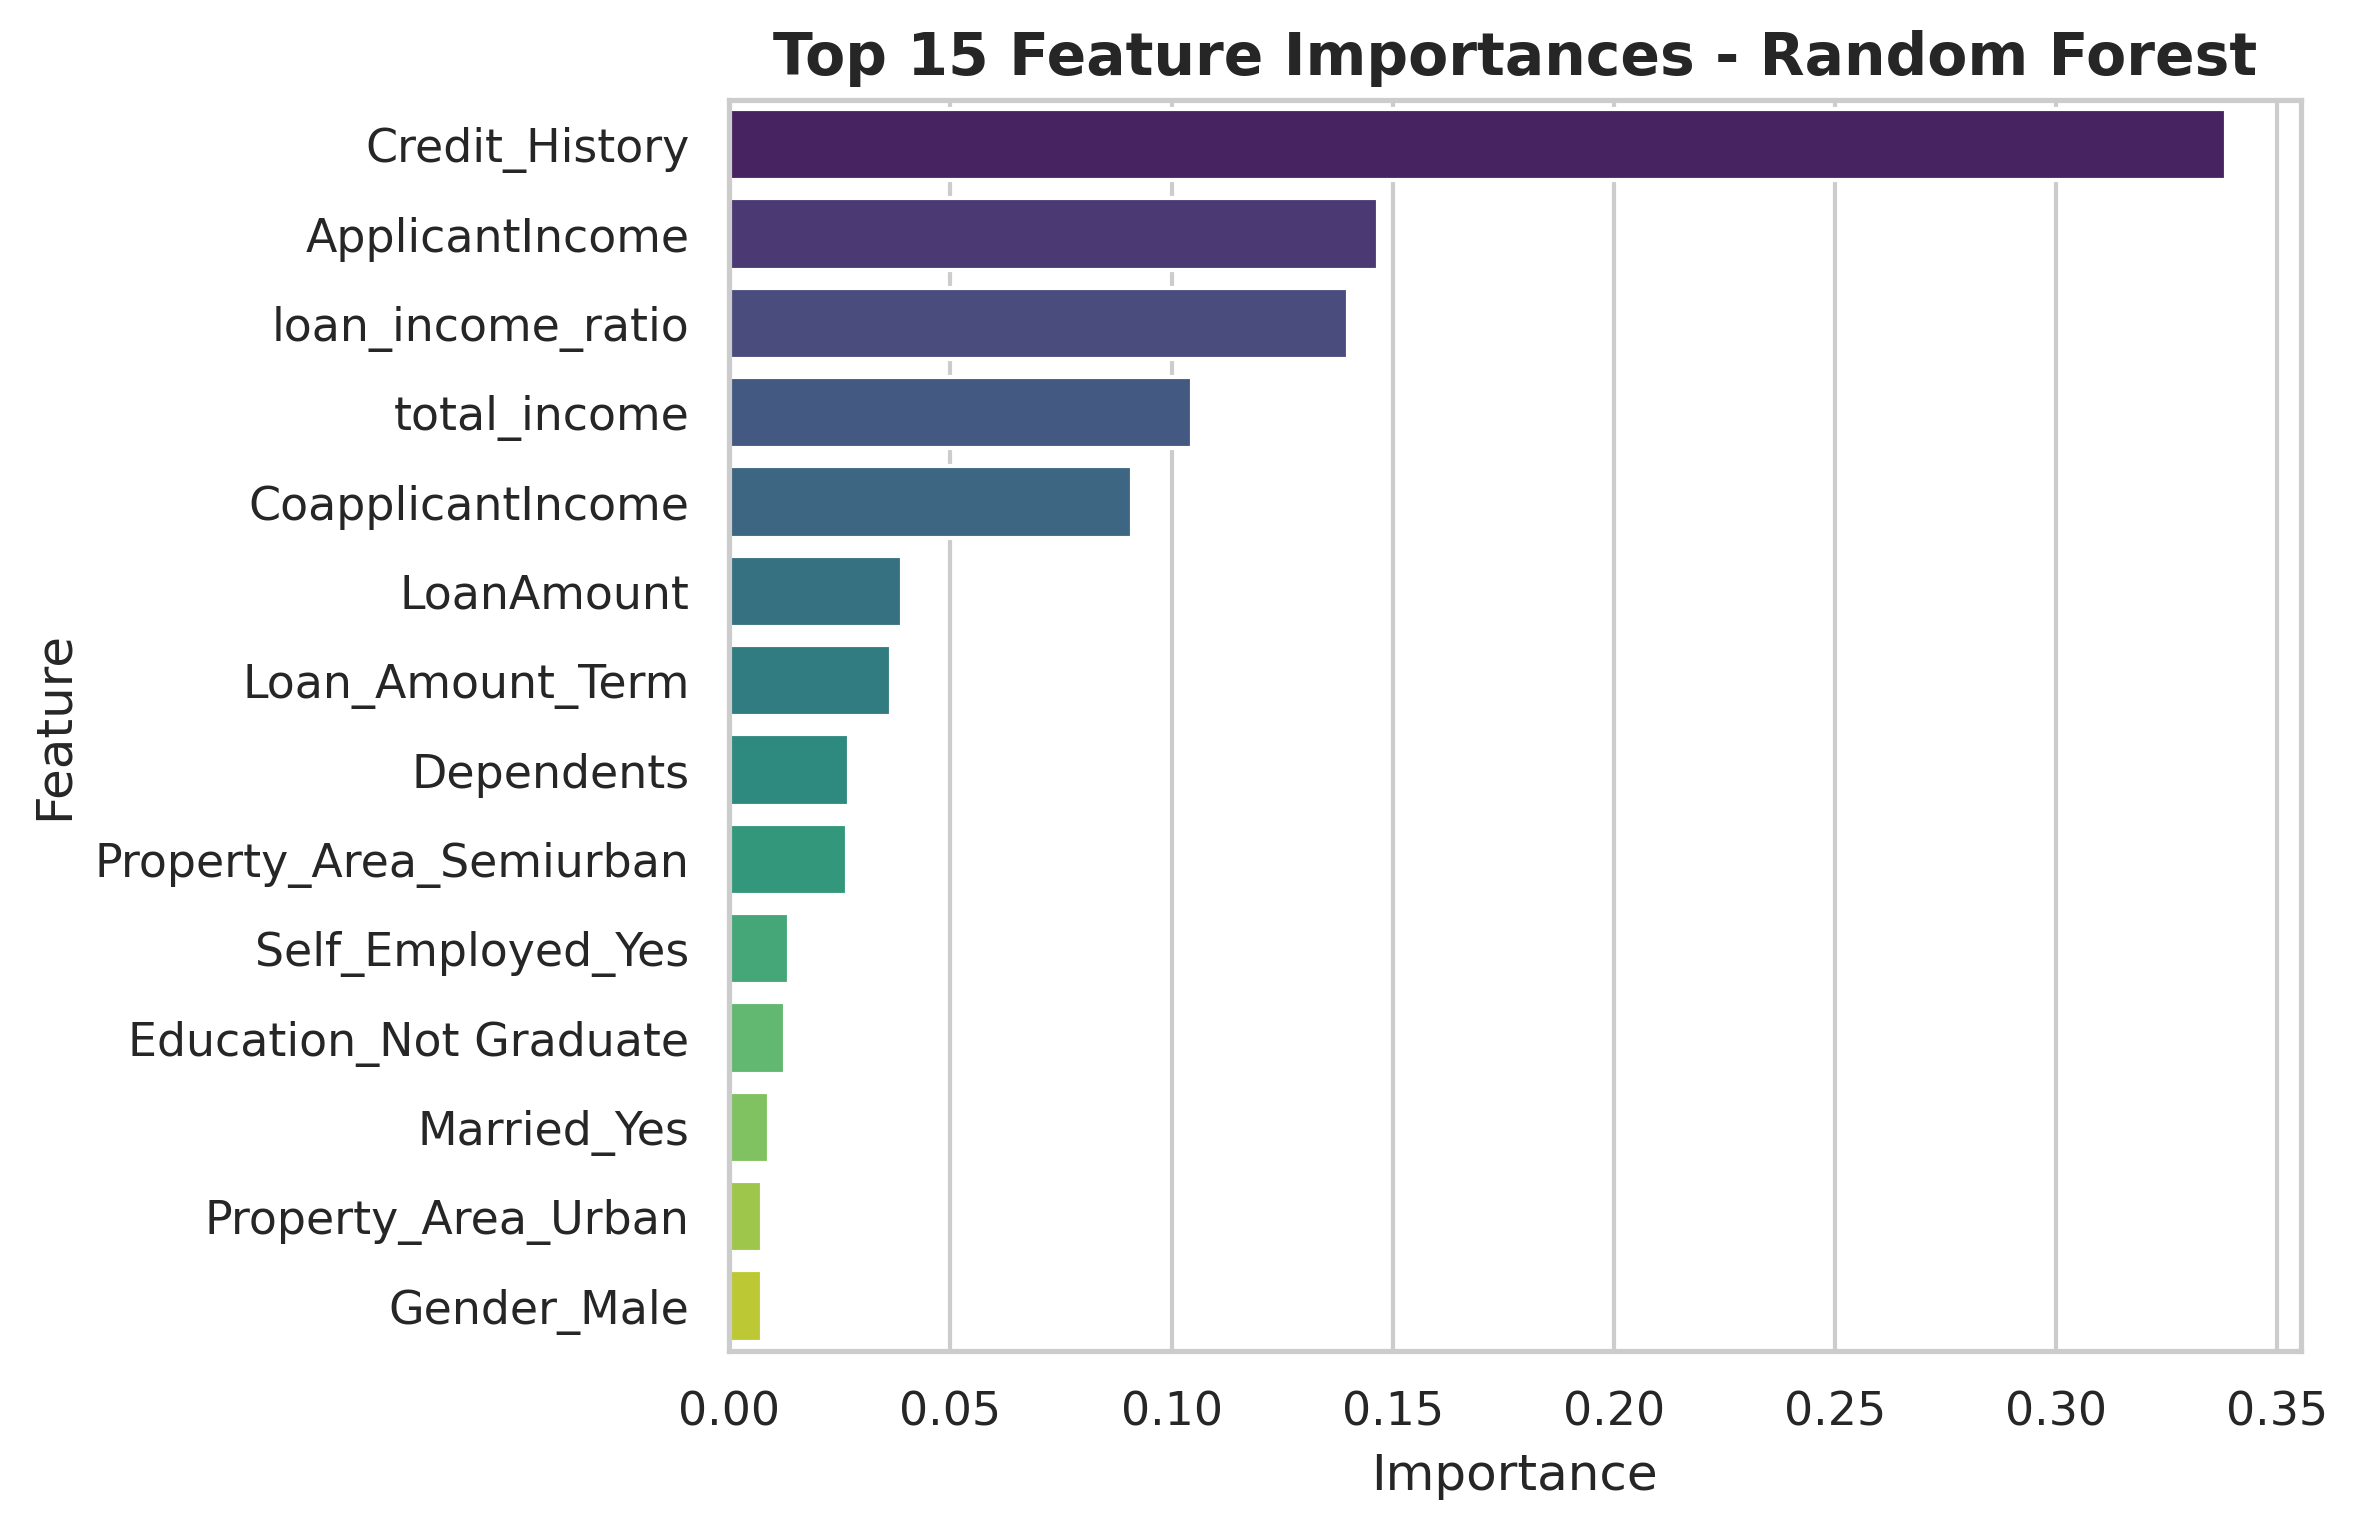

In [5]:
display(Image(filename=str(config.IMAGES_DIR / 'feature_importance.png')))

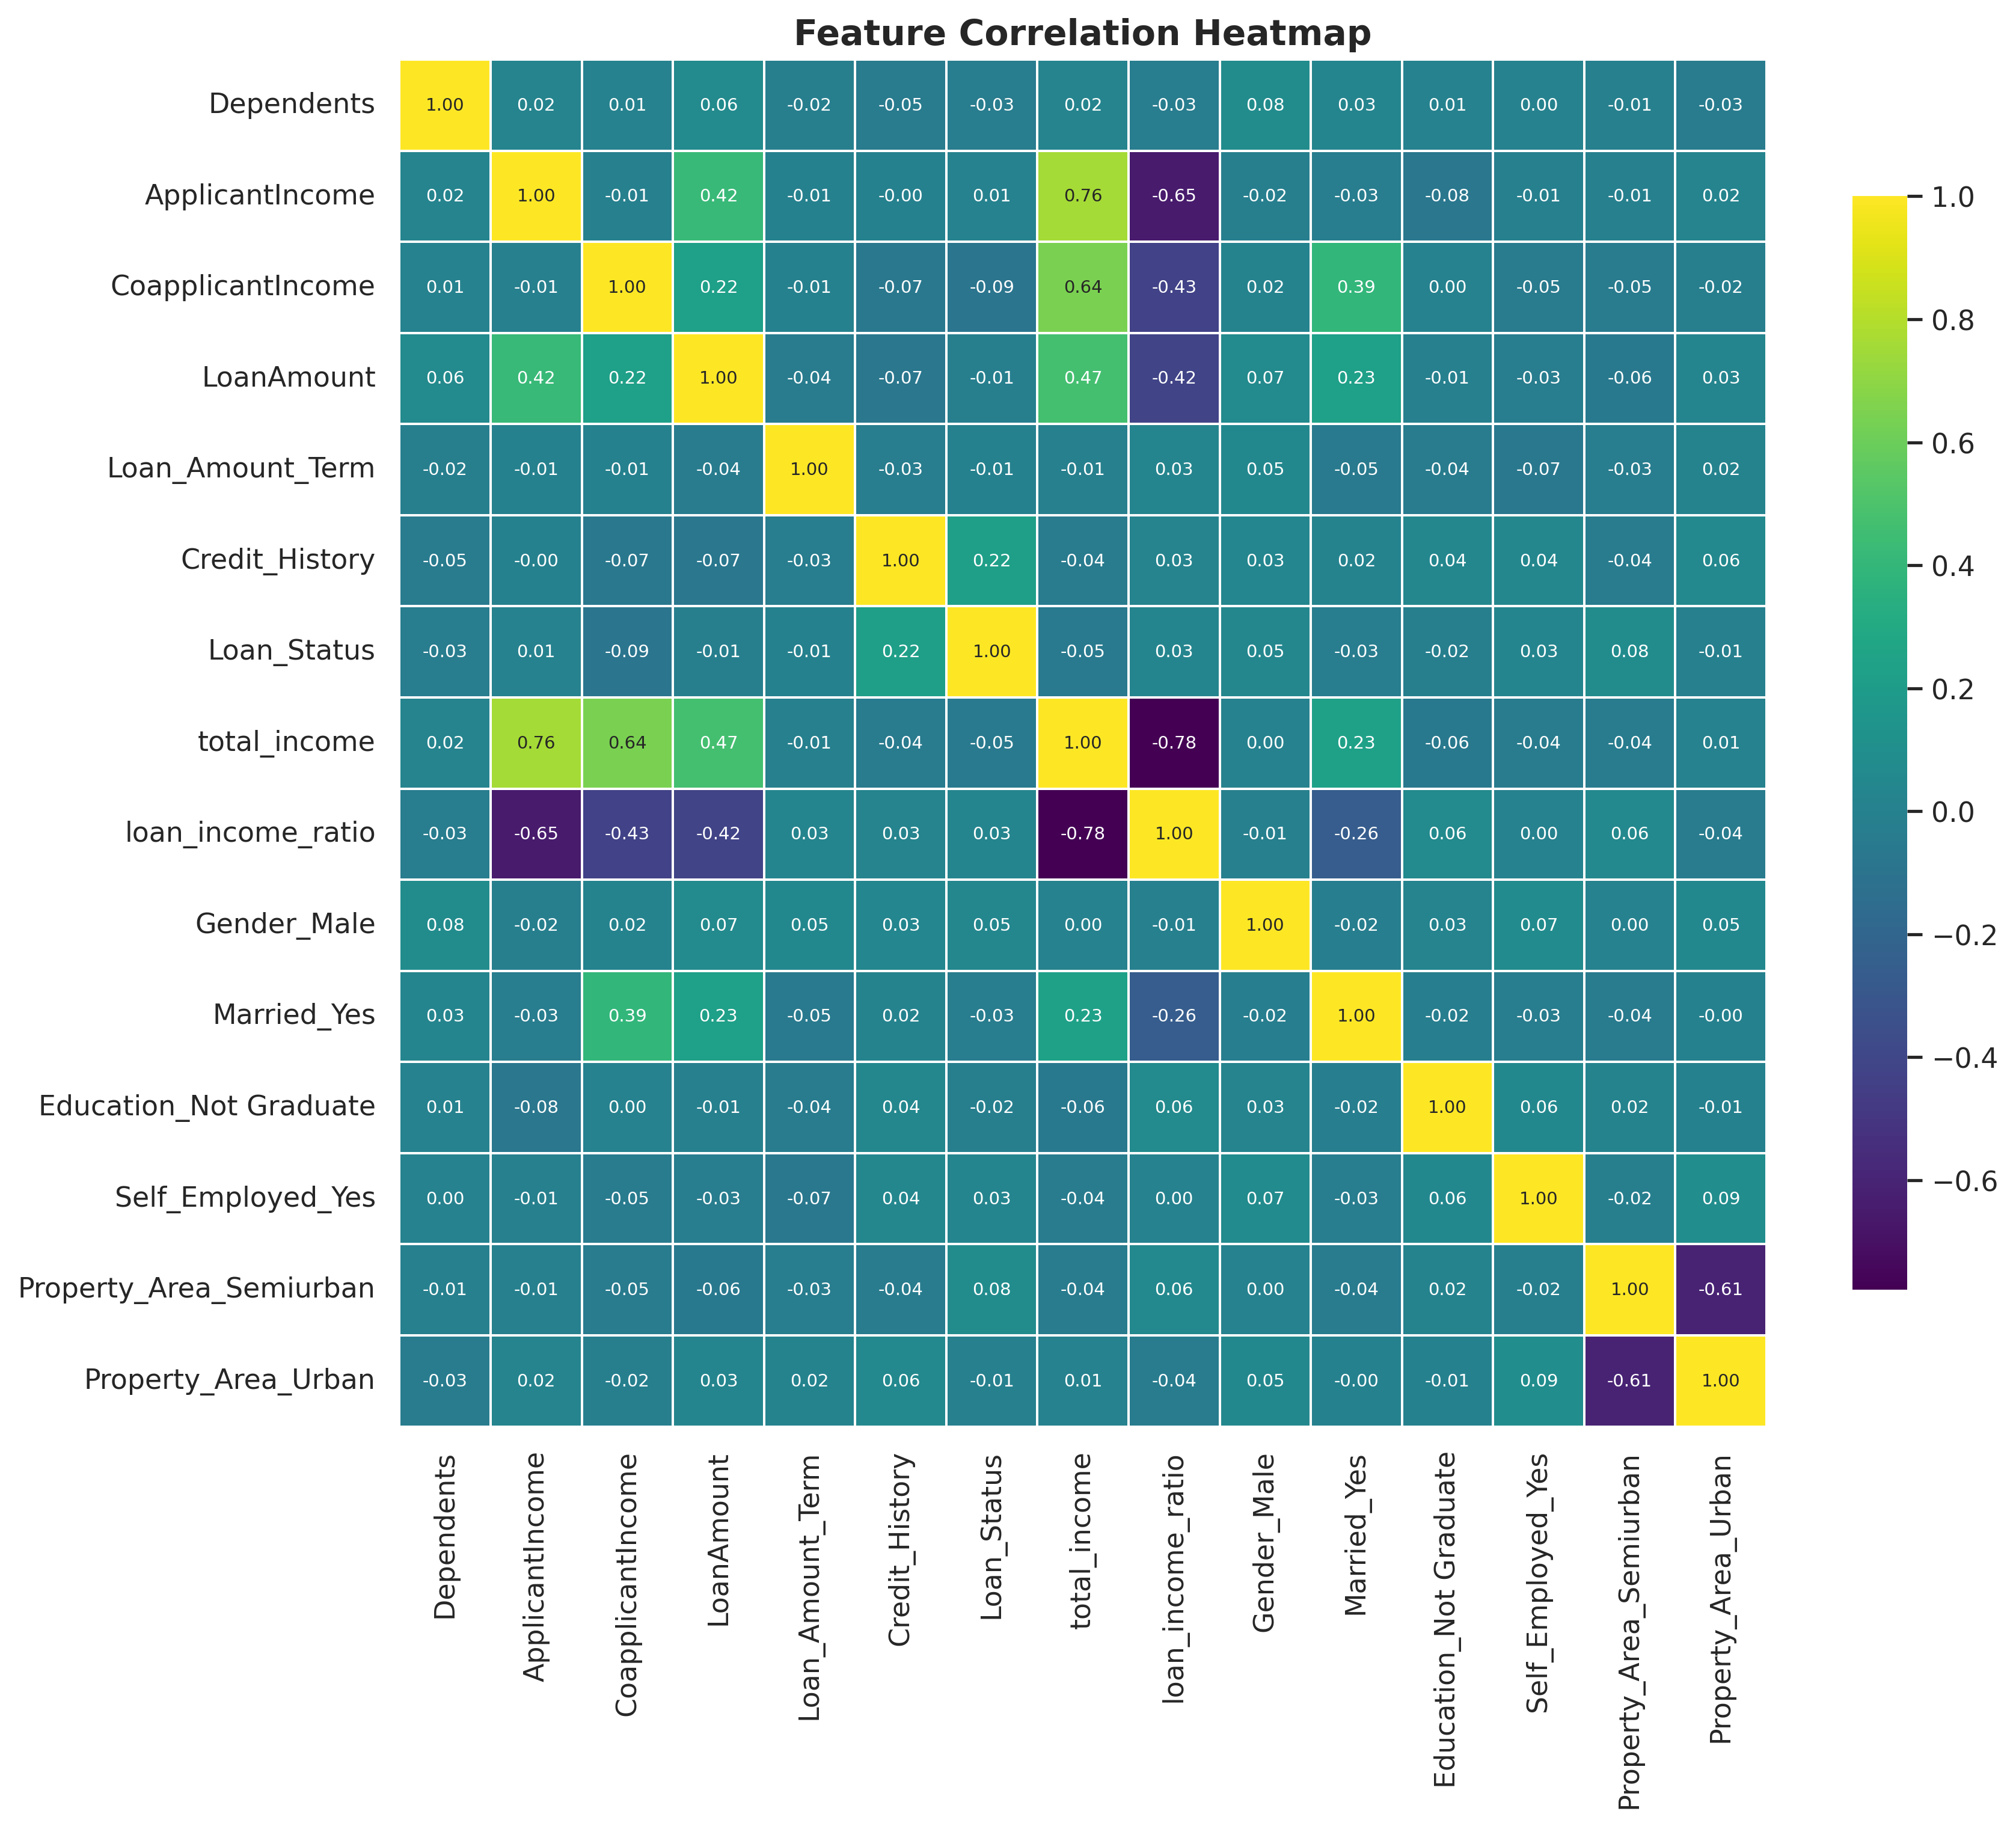

In [6]:
display(Image(filename=str(config.IMAGES_DIR / 'correlation_heatmap.png')))

## 4. Deployment Recommendation

The full deployment recommendation report is available at `reports/deployment_recommendation.md`. It is rendered below.

In [7]:
with open(config.DEPLOYMENT_REPORT_PATH) as f:
    report_content = f.read()
display(Markdown(report_content))

# Deployment Recommendation Report
## Loan Risk Assessment System

---

## 1. Executive Summary

This report compares three classification models trained to predict loan
approval outcomes: **Logistic Regression**, **Decision Tree**, and
**Random Forest**. Based on a comprehensive evaluation across Accuracy,
Precision, Recall, F1 Score, and ROC-AUC, we recommend deploying the
**Random Forest** model in the banking production environment.

---

## 2. Model Comparison Table

| Model               |   Accuracy |   Precision |   Recall |   F1 Score |   ROC AUC |
|:--------------------|-----------:|------------:|---------:|-----------:|----------:|
| Random Forest       |     0.748  |      0.802  |   0.8804 |     0.8394 |    0.6855 |
| Logistic Regression |     0.7154 |      0.8132 |   0.8043 |     0.8087 |    0.6739 |
| Decision Tree       |     0.7073 |      0.8111 |   0.7935 |     0.8022 |    0.6648 |

---

## 3. Metric-by-Metric Analysis

### Precision
Precision measures the proportion of predicted approvals that are truly
creditworthy. In a banking context, low precision means the bank
extends credit to applicants who are likely to default, directly
increasing **credit risk and non-performing assets (NPA)**.

### Recall
Recall measures the proportion of truly creditworthy applicants that the
model correctly approves. Low recall means the bank **rejects good
customers**, resulting in lost business opportunity and poor customer
experience.

### ROC-AUC
ROC-AUC summarizes the model's ability to discriminate between approved
and rejected applicants across all classification thresholds, making it
the most robust metric for comparing models independent of a specific
decision threshold — which is critical since banks often adjust
thresholds based on risk appetite and economic conditions.

---

## 4. Recommended Model: Random Forest

**Key metrics for Random Forest:**

| Metric | Score |
|---|---|
| Accuracy | 0.7480 |
| Precision | 0.8020 |
| Recall | 0.8804 |
| F1 Score | 0.8394 |
| ROC AUC | 0.6855 |

### Justification

1. **Highest discriminative power**: Random Forest achieved the highest
   ROC-AUC score among all candidates, indicating superior ability to
   rank applicants by true creditworthiness across all decision thresholds.
2. **Balanced precision-recall trade-off**: The model does not
   over-optimize for one metric at the expense of the other, which is
   essential in banking where both false approvals (credit risk) and
   false rejections (lost revenue) carry real financial cost.
3. **Interpretability & auditability**: Tree-based models (Decision
   Tree / Random Forest) provide feature importance rankings that support
   regulatory requirements for explainable credit decisions, while
   Logistic Regression provides transparent, coefficient-based
   interpretability valued in credit scoring.
4. **Robustness**: Ensemble methods such as Random Forest reduce
   overfitting risk relative to a single Decision Tree by averaging
   predictions across many de-correlated trees, generally yielding more
   stable performance on unseen applicant populations.

---

## 5. Risk Considerations for Production Deployment

- **Model monitoring**: Continuously monitor for data drift in applicant
  demographics and macroeconomic conditions (interest rates, unemployment)
  that could degrade model performance over time.
- **Fairness & compliance**: Periodically audit approval rates across
  protected attributes (e.g. gender) to ensure compliance with fair
  lending regulations.
- **Threshold calibration**: The deployed decision threshold should be
  calibrated to the bank's specific risk appetite rather than using the
  default 0.5 cutoff, and should be reviewed periodically by the credit
  risk committee.
- **Human-in-the-loop**: Borderline predictions (probabilities near the
  decision threshold) should be routed to human underwriters for manual
  review rather than fully automated decisioning.

---

## 6. Conclusion

The **Random Forest** model is recommended for deployment in the banking
loan approval workflow based on its superior ROC-AUC and balanced
performance across all evaluation metrics. Deployment should be
accompanied by ongoing monitoring, periodic retraining, and a
human-in-the-loop review process for borderline cases.

---
*Report generated automatically by the Loan Risk Assessment System pipeline.*


## 5. Conclusion & Future Improvements

**Conclusion:** Based on the comparative evaluation above, the highest ROC-AUC model is recommended for deployment in the banking loan approval workflow, balancing precision (minimizing bad-loan approvals) and recall (minimizing lost good-customer opportunities).

**Future Improvements:**
- Incorporate additional applicant data (e.g. employment history length, existing debt-to-income ratio, bureau credit score) to improve predictive power.
- Explore gradient boosting models (XGBoost, LightGBM) for potentially higher ROC-AUC.
- Apply SHAP values for per-applicant explainability to support regulatory and customer-facing transparency requirements.
- Build a monitoring dashboard to track model performance and data drift in production.
- Conduct a fairness audit across protected demographic attributes prior to full production rollout.